Usando dispositivo: cpu
Calculando SHAP values (esto puede tomar un par de minutos)...
Generando gráficos explicativos...


<Figure size 1200x600 with 0 Axes>

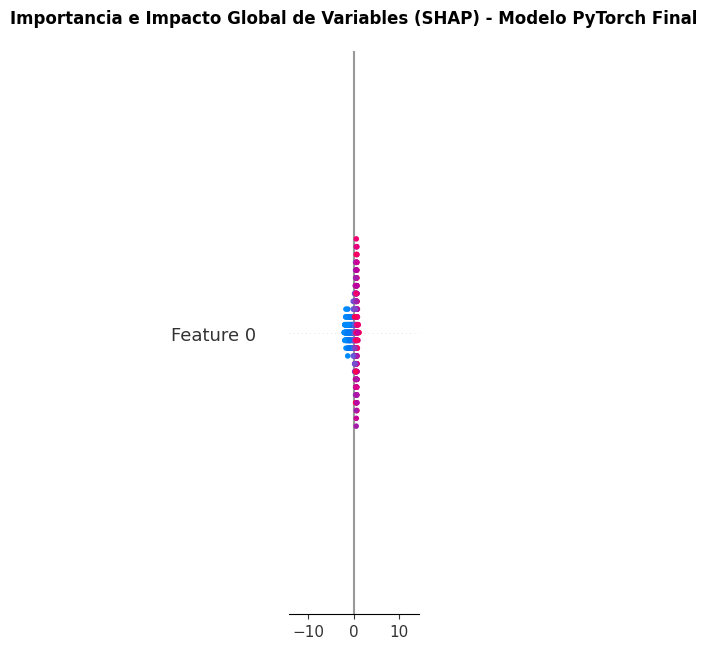

<Figure size 1200x600 with 0 Axes>

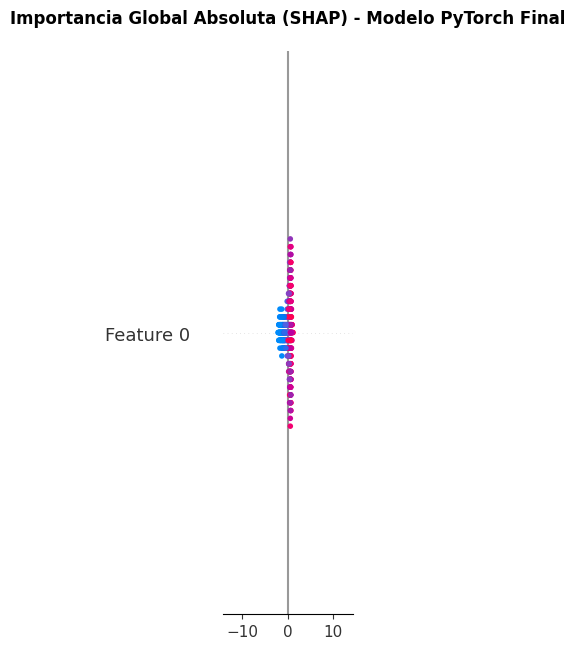

In [3]:
import os
import joblib
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")  # Para evitar mensajes de advertencia innecesarios
# 1. Configurar el mismo dispositivo (CPU o GPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {DEVICE}")

# 2. CARGAR LOS DATOS CORRECTOS (Pipeline Log)
# Usamos el full para el background de SHAP y el de test para generar las explicaciones
X_train_log_full = np.load("transform/X_train_log.npy")
X_test_log       = np.load("transform/X_test_log.npy")

# Si tienes los nombres de las columnas guardados en algún lado (ej. un archivo o lista), 
# puedes definirlo aquí para que el gráfico muestre los nombres de las variables:
# feature_names = ["edad", "capital-gain", ...] 
feature_names = [f"Feature {i}" for i in range(X_train_log_full.shape[1])] 

# 3. RECONSTRUIR LA ARQUITECTURA E IDENTIDIDAD DEL MODELO
# Cargamos los hiperparámetros que guardaste en el .pkl
arch_info = joblib.load("modelo_final/arquitectura_pytorch.pkl")

def build_tuned_model(capas: list, dropout: float, input_dim: int) -> torch.nn.Module:
    layers_list, prev = [], input_dim
    for n in capas:
        layers_list += [torch.nn.Linear(prev, n), torch.nn.ReLU(),
                        torch.nn.BatchNorm1d(n), torch.nn.Dropout(dropout)]
        prev = n
    layers_list += [torch.nn.Linear(prev, 1)]
    return torch.nn.Sequential(*layers_list)

# Instanciamos el modelo vacío con la configuración correcta
modelo_final = build_tuned_model(
    capas=arch_info["capas"], 
    dropout=arch_info["dropout"], 
    input_dim=arch_info["input_dim"]
)

# 4. CARGAR LOS PESOS DESDE EL ARCHIVO .pt
modelo_final.load_state_dict(torch.load("modelo_final/modelo_pytorch_final.pt", map_location=DEVICE))
modelo_final.to(DEVICE)
modelo_final.eval() # OBLIGATORIO: Desactiva capas de Dropout y BatchNorm para SHAP

# 5. PREPARAR LOS DATOS PARA DEEP LEARNING (Muestreo y Tensores)
# Regla de oro: No pases todo el X_train, colapsará la memoria. Tomamos una muestra aleatoria (Background)
np.random.seed(42)
idx_bg = np.random.choice(X_train_log_full.shape[0], size=200, replace=False)
background_np = X_train_log_full[idx_bg].astype(np.float32)

# Tomamos una muestra del set de prueba para explicar (ej: 500 registros)
idx_test = np.random.choice(X_test_log.shape[0], size=500, replace=False)
X_test_sample_np = X_test_log[idx_test].astype(np.float32)

# Convertimos estrictamente a tensores de PyTorch en el dispositivo correcto
background_tensor = torch.from_numpy(background_np).to(DEVICE)
X_test_tensor = torch.from_numpy(X_test_sample_np).to(DEVICE)

# 6. INICIALIZAR SHAP DEEP EXPLAINDER
# DeepExplainer es el algoritmo optimizado para redes neuronales en PyTorch
explainer = shap.DeepExplainer(modelo_final, background_tensor)

# 7. CALCULAR LOS SHAP VALUES
print("Calculando SHAP values (esto puede tomar un par de minutos)...")
shap_values = explainer.shap_values(X_test_tensor)

# Si la salida es una lista debido a las dimensiones de PyTorch, extraemos el array
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# 8. GENERAR LAS VISUALIZACIONES
print("Generando gráficos explicativos...")

# A. Gráfico Global (Beeswarm / Summary Plot)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_sample_np, feature_names=feature_names, show=False)
plt.title("Importancia e Impacto Global de Variables (SHAP) - Modelo PyTorch Final", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("plots/modelos_pytorch/shap_summary_pytorch.png", dpi=300, bbox_inches='tight')
plt.show()

# B. Gráfico de Barras de Magnitud Pura
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test_sample_np, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Importancia Global Absoluta (SHAP) - Modelo PyTorch Final", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("plots/modelos_pytorch/shap_bar_pytorch.png", dpi=300, bbox_inches='tight')
plt.show()